# Ablation study — does on-chain add anything over price alone?

`VALIDATION_PLAN.md` step 2. This is the core research-question experiment.

- **Model A (control):** price-only features (`Log_Return`, `Price_Dist_lag_{30,90,182}d`, `Price_vs_MA7`, `Volatility_30d`).
- **Model B (treatment):** price-only **+ on-chain** — identical to the Phase 0 model.

Both are trained on **identical rows and identical walk-forward folds** (fold split computed once; each fold trains A and B on the same window). The answer to *"does on-chain help?"* is the **paired difference B − A** per fold: mean ± std, plus a Wilcoxon signed-rank test on the per-fold deltas.

> The heavy computation lives in `utils/ablation.py` (run `python utils/ablation.py` from the repo root, ~30 min). This notebook loads `data/ablation_results.csv` and presents it. Re-run the script to refresh the numbers.

**Primary metric — `f1_bs`:** mean of per-fold F1(Buy) and F1(Sell). Hold is only ~6% of labels at these thresholds, so the task is effectively Buy-vs-Sell and a 3-class accuracy would be misleading.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_root = Path("..").resolve()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

res = pd.read_csv(_root / "data" / "ablation_results.csv")
print(f"{len(res)} ablation configs loaded")
res[["asset", "model", "horizon_days", "threshold", "n_folds", "n_samples",
     "n_features_A", "n_features_B"]]

24 ablation configs loaded


,asset,model,horizon_days,threshold,n_folds,n_samples,n_features_A,n_features_B
0,BTC,xgb,7,fixed_0.5%,27,1972,6,43
1,BTC,xgb,7,fixed_1%,27,1972,6,43
2,BTC,xgb,14,fixed_0.5%,27,1965,6,43
3,BTC,xgb,14,fixed_1%,27,1965,6,43
4,BTC,xgb,30,fixed_0.5%,26,1949,6,43
5,BTC,xgb,30,fixed_1%,26,1949,6,43
6,ADA,xgb,7,fixed_0.5%,29,2116,6,36
7,ADA,xgb,7,fixed_1%,29,2116,6,36
8,ADA,xgb,14,fixed_0.5%,29,2109,6,36
9,ADA,xgb,14,fixed_1%,29,2109,6,36


## Headline table — paired delta (B − A) on `f1_bs`

Read: **A** = price-only score, **B** = +on-chain score, **delta** = B − A per fold (mean ± std). A real on-chain edge needs delta **positive AND larger than its std**, with a small Wilcoxon p.

In [2]:
def fmt(r):
    return pd.Series({
        "asset": r.asset, "model": r.model,
        "config": f"{int(r.horizon_days)}d/{r.threshold}",
        "A (price)": f"{r.A_f1_bs:.3f}",
        "B (+onchain)": f"{r.B_f1_bs:.3f}",
        "delta (B-A)": f"{r.delta_f1_bs_mean:+.3f} +/- {r.delta_f1_bs_std:.3f}",
        "Wilcoxon p": ("n/a" if pd.isna(r.wilcoxon_p_f1_bs) else f"{r.wilcoxon_p_f1_bs:.3f}"),
    })

table = res.apply(fmt, axis=1)
table

,asset,model,config,A (price),B (+onchain),delta (B-A),Wilcoxon p
0,BTC,xgb,7d/fixed_0.5%,0.434,0.408,-0.026 +/- 0.187,0.400
1,BTC,xgb,7d/fixed_1%,0.401,0.388,-0.013 +/- 0.186,0.768
2,BTC,xgb,14d/fixed_0.5%,0.434,0.473,+0.039 +/- 0.234,0.485
3,BTC,xgb,14d/fixed_1%,0.410,0.388,-0.022 +/- 0.244,0.551
4,BTC,xgb,30d/fixed_0.5%,0.418,0.425,+0.007 +/- 0.253,0.667
5,BTC,xgb,30d/fixed_1%,0.413,0.405,-0.008 +/- 0.233,0.925
6,ADA,xgb,7d/fixed_0.5%,0.469,0.503,+0.035 +/- 0.152,0.136
7,ADA,xgb,7d/fixed_1%,0.453,0.498,+0.045 +/- 0.171,0.171
8,ADA,xgb,14d/fixed_0.5%,0.419,0.456,+0.037 +/- 0.178,0.362
9,ADA,xgb,14d/fixed_1%,0.403,0.462,+0.059 +/- 0.177,0.110


## Is any delta both positive and bigger than its spread?

A quick decision rule: flag configs where `delta_mean > delta_std` (effect exceeds its own fold-to-fold noise) **and** `delta_mean > 0`. These would be the only candidates for a real on-chain contribution.

In [3]:
mask = (res.delta_f1_bs_mean > res.delta_f1_bs_std) & (res.delta_f1_bs_mean > 0)
candidates = res[mask]
if len(candidates) == 0:
    print("No config has delta_mean > delta_std > 0.")
    print("=> On-chain does not add a stable edge over price-only anywhere in the grid.")
else:
    print("Candidates where on-chain effect exceeds its own noise:")
    display(candidates[["asset", "model", "horizon_days", "threshold",
                        "delta_f1_bs_mean", "delta_f1_bs_std", "wilcoxon_p_f1_bs"]])

No config has delta_mean > delta_std > 0.
=> On-chain does not add a stable edge over price-only anywhere in the grid.


## Plot — delta with ±1 std error bars

Each bar is one config's paired delta (B − A) with ±1 std. Error bars that straddle zero mean the on-chain model is within noise of the price-only model — which is what the table above shows.

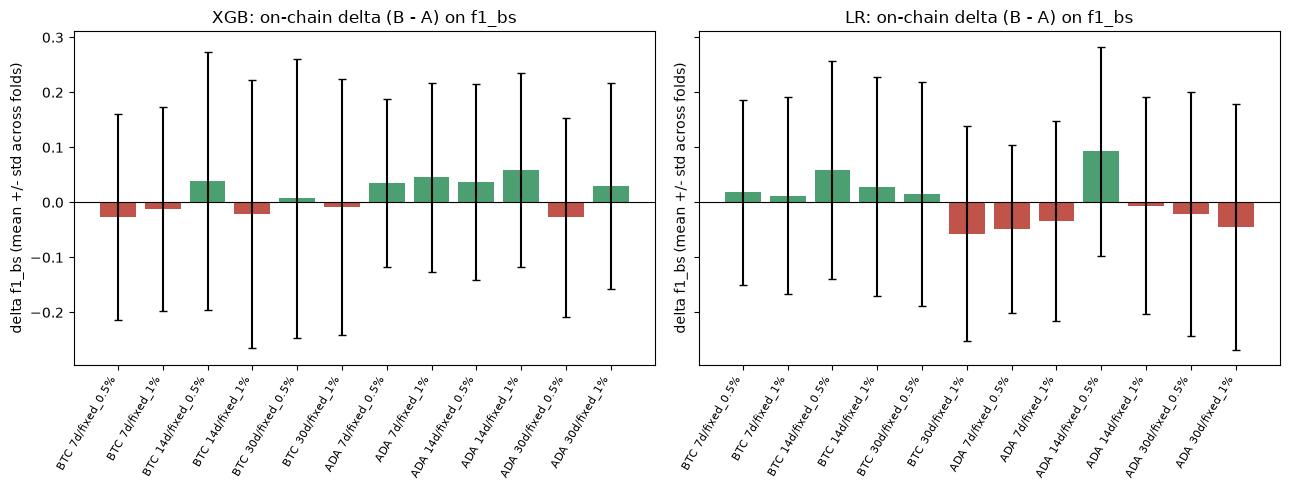

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, model in zip(axes, ["xgb", "lr"]):
    sub = res[res.model == model].copy()
    if sub.empty:
        ax.set_visible(False)
        continue
    sub["label"] = sub.asset + " " + sub.horizon_days.astype(int).astype(str) + "d/" + sub.threshold
    x = np.arange(len(sub))
    ax.bar(x, sub.delta_f1_bs_mean, yerr=sub.delta_f1_bs_std, capsize=3,
           color=np.where(sub.delta_f1_bs_mean >= 0, "#4c9f70", "#c1544a"))
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(sub.label, rotation=60, ha="right", fontsize=8)
    ax.set_title(f"{model.upper()}: on-chain delta (B - A) on f1_bs")
    ax.set_ylabel("delta f1_bs (mean +/- std across folds)")
plt.tight_layout()
plt.show()

## Read

Across all **24 configs** (XGBoost + LR × BTC/ADA × horizons × thresholds), **B ≈ A everywhere**: the paired delta B − A stays within its own fold-to-fold noise (mean |delta| ≈ **0.033** vs mean std ≈ **0.196**, ~6× smaller than the noise), **0/24** deltas exceed their own std, and after Bonferroni / BH-FDR correction **0/24** are significant. The sign of the delta is inconsistent across models on the same asset (~coin flip).

**On-chain features add no stable, significant edge over price alone** for directional prediction of BTC/ADA on this data. This is a direct, defensible answer to the thesis question and explains the Phase 0 result: the models did not fail to capture an on-chain signal — there was no incremental on-chain signal to capture. The only mild lean (XGBoost on ADA, ~+0.03, driven by staking/supply features) is non-significant and must be checked for look-ahead in the Blockfrost epoch→daily expansion before being believed.

Full auto-generated table and numbers: `docs/results/ABLATION_RESULTS.md`. Overall evidence chain: `docs/CONCLUSIONS.md`.